In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)  # so you can see all columns when printing
%matplotlib inline

In [2]:
df = pd.read_csv('lending_club_loan_two.csv')
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,Not Verified,Jan-2015,Fully Paid,vacation,Vacation,26.24,Jun-1990,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,Not Verified,Jan-2015,Fully Paid,debt_consolidation,Debt consolidation,22.05,Jul-2004,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,Source Verified,Jan-2015,Fully Paid,credit_card,Credit card refinancing,12.79,Aug-2007,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,Not Verified,Nov-2014,Fully Paid,credit_card,Credit card refinancing,2.60,Sep-2006,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,Verified,Apr-2013,Charged Off,credit_card,Credit Card Refinance,33.95,Mar-1999,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


In [3]:
df.info()          # shows every column, its data type, and how many values are missing
df.describe()       # statistical summary of numeric columns
df['loan_status'].value_counts()   # how many paid vs defaulted

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

loan_status
Fully Paid     318357
Charged Off     77673
Name: count, dtype: int64

In [4]:
df['loan_repaid'] = df['loan_status'].map({'Fully Paid': 1, 'Charged Off': 0})

In [5]:
df.isnull().sum().sort_values(ascending=False)

mort_acc                37795
emp_title               22927
emp_length              18301
title                    1756
pub_rec_bankruptcies      535
revol_util                276
dti                         0
address                     0
application_type            0
initial_list_status         0
total_acc                   0
revol_bal                   0
pub_rec                     0
open_acc                    0
earliest_cr_line            0
loan_amnt                   0
term                        0
purpose                     0
loan_status                 0
issue_d                     0
verification_status         0
annual_inc                  0
home_ownership              0
sub_grade                   0
grade                       0
installment                 0
int_rate                    0
loan_repaid                 0
dtype: int64

Text(0.5, 1.0, 'Loan Repaid (1) vs Defaulted (0)')

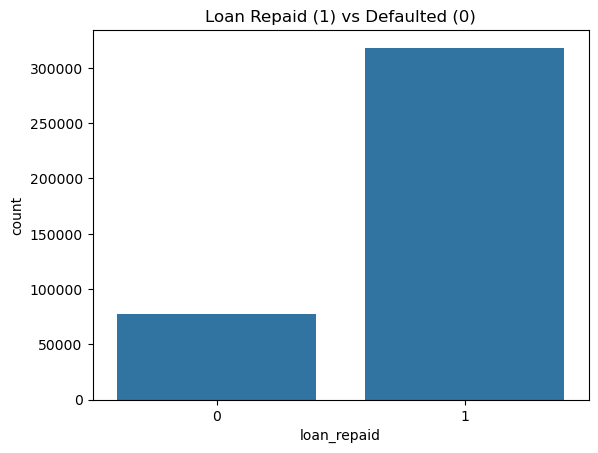

In [6]:
sns.countplot(x='loan_repaid', data=df)
plt.title('Loan Repaid (1) vs Defaulted (0)')

<Axes: xlabel='loan_status', ylabel='loan_amnt'>

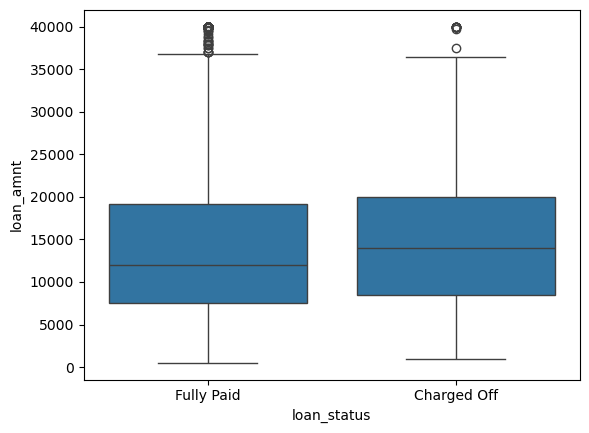

In [7]:
# Does loan amount differ between paid and defaulted loans?
sns.boxplot(x='loan_status', y='loan_amnt', data=df)

<Axes: >

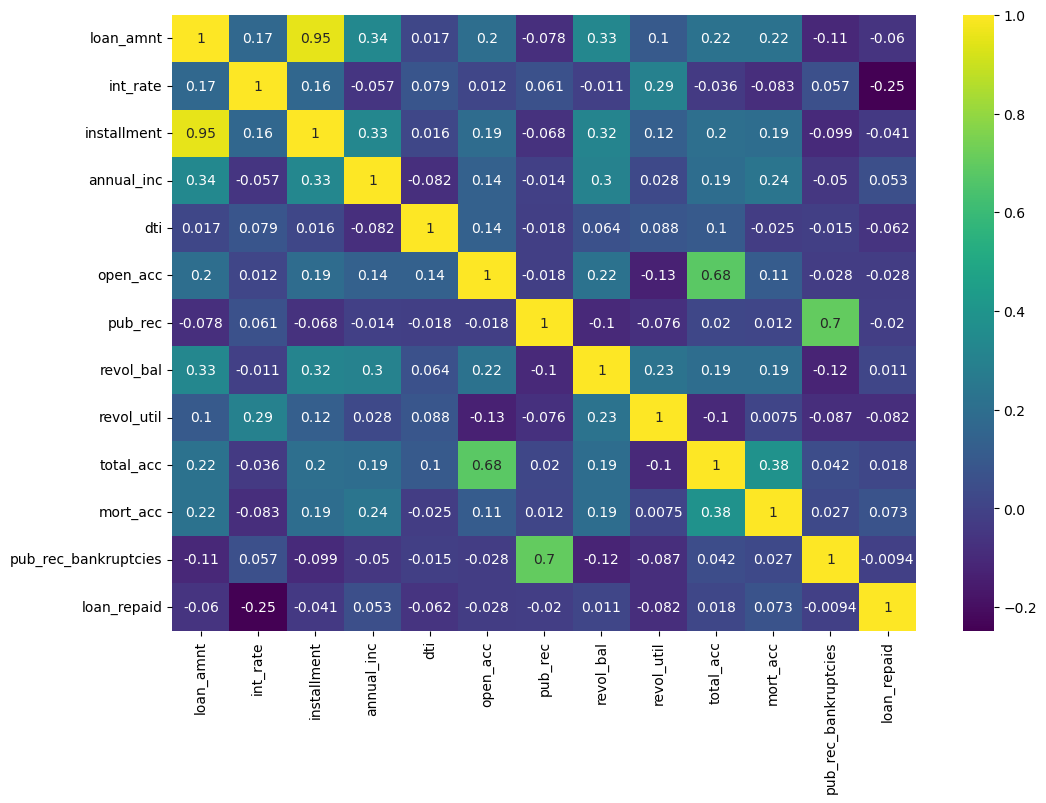

In [8]:
# Correlation between numeric features and repayment
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='viridis')

<Axes: xlabel='grade', ylabel='count'>

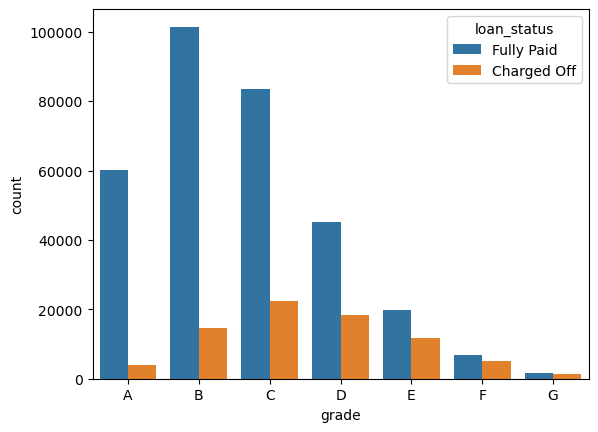

In [9]:
# Does loan grade (A-G, assigned by LendingClub) predict default?
sns.countplot(x='grade', hue='loan_status', data=df, order=sorted(df['grade'].unique()))

In [10]:
#cleaning data
df = df.drop(['emp_title', 'title', 'grade'], axis=1)
# we drop 'grade' here because 'sub_grade' contains the same info in more detail

In [11]:
#emp_length has some missing values — fill with the most common category
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].mode()[0])

#mort_acc (number of mortgage accounts) — fill with median grouped by total_acc
total_acc_avg = df.groupby('total_acc')['mort_acc'].mean()
def fill_mort_acc(total_acc, mort_acc):
    if pd.isnull(mort_acc):
        return total_acc_avg[total_acc]
    return mort_acc

df['mort_acc'] = df.apply(lambda row: fill_mort_acc(row['total_acc'], row['mort_acc']), axis=1)

# Drop any remaining rows with missing values in less important columns
df = df.dropna()

In [12]:
df['term'] = df['term'].apply(lambda x: int(x.split()[0]))  # "36 months" -> 36

dummies = pd.get_dummies(df[['sub_grade', 'verification_status', 'application_type',
                              'home_ownership', 'purpose', 'initial_list_status']],
                          drop_first=True)
df = pd.concat([df.drop(['sub_grade', 'verification_status', 'application_type',
                          'home_ownership', 'purpose', 'initial_list_status'], axis=1),
                dummies], axis=1)

In [13]:
df = df.drop(['issue_d', 'address'], axis=1)

In [14]:
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)
df['emp_length'] = df['emp_length'].replace({
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10
})

# Extract just the year from earliest credit line — older credit history = lower risk
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line']).dt.year

C:\Users\Nishitha\AppData\Local\Temp\ipykernel_10820\792752788.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['emp_length'] = df['emp_length'].replace({
C:\Users\Nishitha\AppData\Local\Temp\ipykernel_10820\792752788.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line']).dt.year


In [15]:
#preparing model

df = df.drop('loan_status', axis=1)   # this is the text version we already encoded as loan_repaid
X = df.drop('loan_repaid', axis=1)
y = df['loan_repaid']

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [19]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


              precision    recall  f1-score   support

           0       0.41      0.30      0.34     15421
           1       0.84      0.90      0.87     63623

    accuracy                           0.78     79044
   macro avg       0.62      0.60      0.61     79044
weighted avg       0.76      0.78      0.77     79044

ROC-AUC: 0.704872140818428


<Axes: >

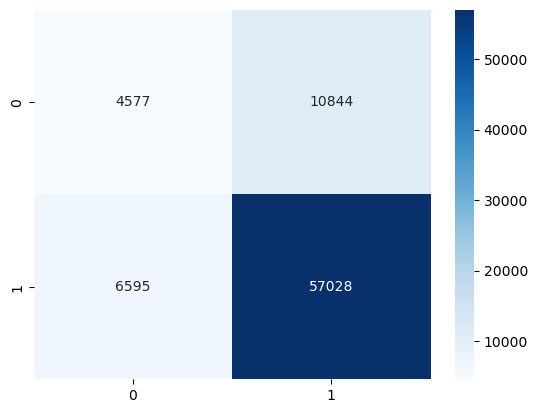

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

preds = log_model.predict(X_test)
probs = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues')

In [21]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf_model = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

xgb_model = XGBClassifier(n_estimators=50, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [22]:
from sklearn.model_selection import GridSearchCV
params = {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7]}
grid = GridSearchCV(XGBClassifier(random_state=42), params, scoring='roc_auc', cv=3)
grid.fit(X_train, y_train)
print(grid.best_params_)

{'max_depth': 5, 'n_estimators': 200}


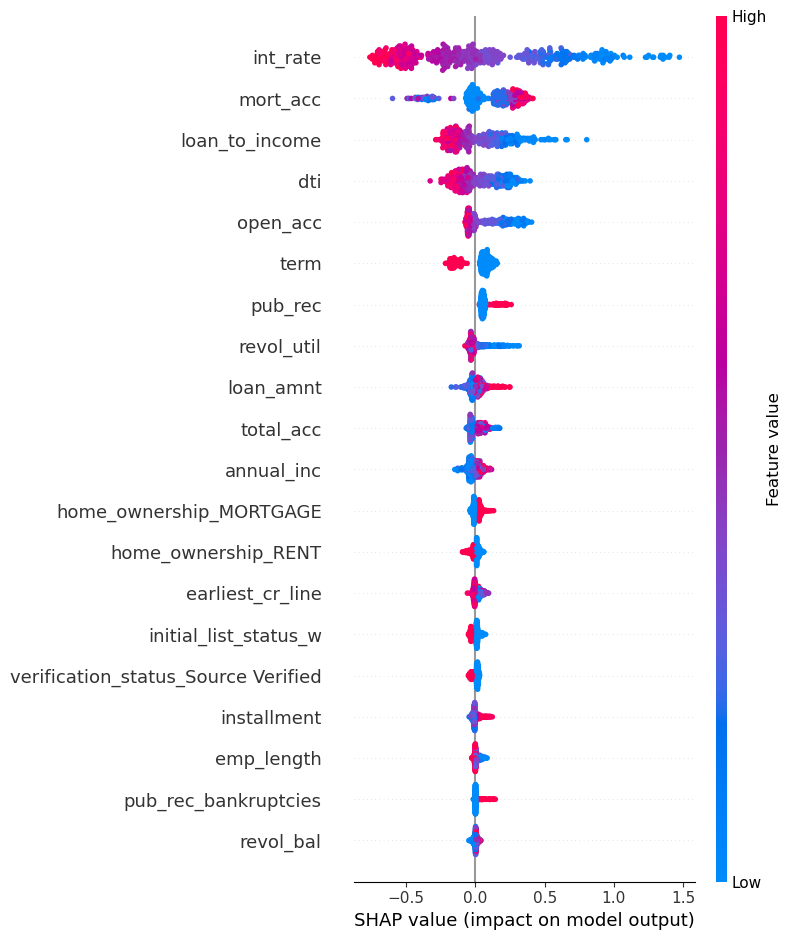

In [23]:
#shap

import shap
explainer = shap.TreeExplainer(xgb_model)
sample = X_test[:500] if not hasattr(X_test, 'sample') else X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, feature_names=X.columns)

In [24]:
from sklearn.metrics import classification_report, roc_auc_score

models = {
    'Logistic Regression': log_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

results = {}
for name, model in models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    print(f"--- {name} ---")
    print(classification_report(y_test, preds))
    print(f"ROC-AUC: {auc:.3f}\n")
    results[name] = auc

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.41      0.30      0.34     15421
           1       0.84      0.90      0.87     63623

    accuracy                           0.78     79044
   macro avg       0.62      0.60      0.61     79044
weighted avg       0.76      0.78      0.77     79044

ROC-AUC: 0.705

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.43      0.19      0.27     15421
           1       0.83      0.94      0.88     63623

    accuracy                           0.79     79044
   macro avg       0.63      0.57      0.57     79044
weighted avg       0.75      0.79      0.76     79044

ROC-AUC: 0.695

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.46      0.15      0.23     15421
           1       0.82      0.96      0.88     63623

    accuracy                           0.80     79044
   macro avg       0.64      0

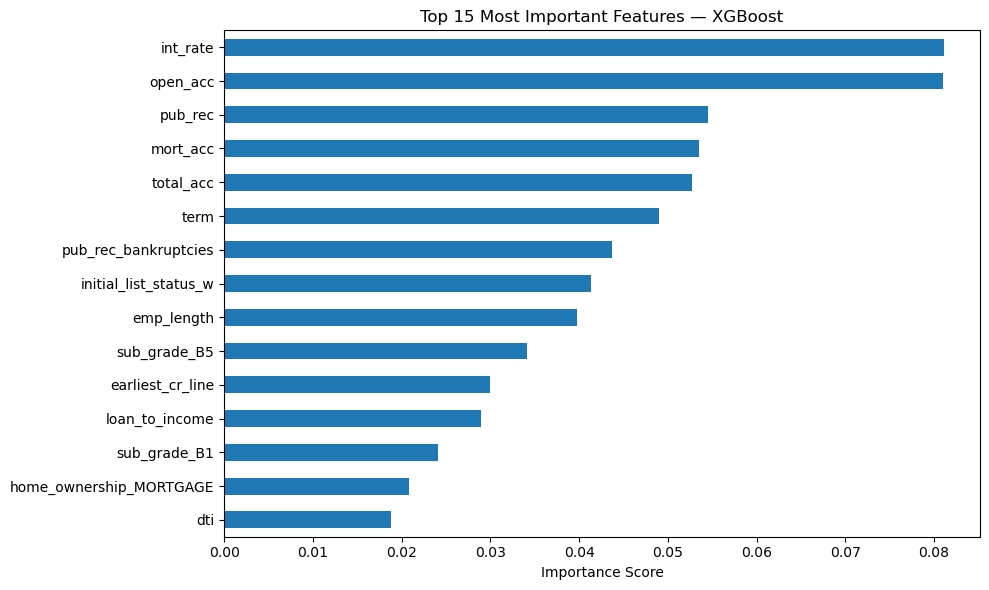

In [25]:
#This saves an image file called feature_importance.png directly into your project folder

import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh')
plt.title('Top 15 Most Important Features — XGBoost')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [26]:
df.shape

(395219, 74)

In [27]:
!pip freeze > requirements.txt